## Imports and Setup


In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import warnings
warnings.filterwarnings('ignore')

import shap
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
import joblib
import os

np.random.seed(42)


## Load Data and Models


In [35]:
prices = pd.read_csv('./dataset/cleaned_data.csv', parse_dates=['Date'], index_col='Date')
predictions = pd.read_csv('./dataset/stage5_stage4_predictions.csv')
candidate_pairs = pd.read_csv('./dataset/cluster_candidate_pairs.csv')
cointegration_results = pd.read_csv('./dataset/cointegration_results.csv')


## Load Stage 5 Models


In [36]:
try:
    rf_model = joblib.load('./dataset/stage5_rf_model.pkl')
    xgb_optimized = joblib.load('./dataset/stage5_xgb_optimized_model.pkl')
    print("Models loaded successfully")
except:
    print("Models not found. Please run Stage 5 and save the models first.")
    rf_model = None
    xgb_optimized = None


Models loaded successfully


## Evaluation Metrics


In [37]:
y_actual = predictions['actual'].values
y_pred_rf = predictions['rf_pred'].values
y_pred_xgb = predictions['xgb_baseline_pred'].values
y_pred_xgb_opt = predictions['xgb_optimized_pred'].values

models_metrics = {}

for name, y_pred in [('Random Forest', y_pred_rf), 
                     ('XGBoost Baseline', y_pred_xgb),
                     ('XGBoost Optimized', y_pred_xgb_opt)]:
    metrics = {
        'accuracy': accuracy_score(y_actual, y_pred),
        'precision': precision_score(y_actual, y_pred, zero_division=0),
        'recall': recall_score(y_actual, y_pred, zero_division=0),
        'f1_score': f1_score(y_actual, y_pred, zero_division=0)
    }
    models_metrics[name] = metrics

metrics_df = pd.DataFrame(models_metrics).T


## Evaluation Metrics


In [38]:
y_actual = predictions['actual'].values
y_pred_rf = predictions['rf_pred'].values
y_pred_xgb = predictions['xgb_baseline_pred'].values
y_pred_xgb_opt = predictions['xgb_optimized_pred'].values

models_metrics = {}

for name, y_pred in [('Random Forest', y_pred_rf), 
                     ('XGBoost Baseline', y_pred_xgb),
                     ('XGBoost Optimized', y_pred_xgb_opt)]:
    metrics = {
        'accuracy': accuracy_score(y_actual, y_pred),
        'precision': precision_score(y_actual, y_pred, zero_division=0),
        'recall': recall_score(y_actual, y_pred, zero_division=0),
        'f1_score': f1_score(y_actual, y_pred, zero_division=0)
    }
    models_metrics[name] = metrics

metrics_df = pd.DataFrame(models_metrics).T


## Helper Functions for Backtesting


In [39]:
def calculate_spread_and_zscore(price1, price2, lookback=60):
    common_dates = price1.index.intersection(price2.index)
    p1 = price1.loc[common_dates]
    p2 = price2.loc[common_dates]
    
    if len(p1) < lookback + 10:
        return None
    
    hedge_ratio = linregress(p1.values, p2.values).slope
    spread = p2 - hedge_ratio * p1
    rolling_mean = spread.rolling(window=lookback).mean()
    rolling_std = spread.rolling(window=lookback).std()
    z_score = (spread - rolling_mean) / rolling_std
    
    return pd.DataFrame({
        'spread': spread,
        'z_score': z_score,
        'hedge_ratio': hedge_ratio,
        'rolling_mean': rolling_mean,
        'rolling_std': rolling_std
    }, index=common_dates)

def calculate_sharpe_ratio(returns, risk_free_rate=0.0):
    if len(returns) == 0 or np.std(returns) == 0:
        return 0.0
    excess_returns = returns - risk_free_rate
    sharpe = np.mean(excess_returns) / np.std(returns) * np.sqrt(252)
    return sharpe


## Backtest Baseline Strategy


In [40]:
top_cointegrated = cointegration_results[cointegration_results['pvalue'] < 0.05].head(50)

baseline_returns = []
baseline_pairs_tested = 0

for idx, row in top_cointegrated.iterrows():
    pair_str = row['pair']
    try:
        ticker1, ticker2 = pair_str.strip('()').replace("'", '').split(', ')
        ticker1 = ticker1.strip()
        ticker2 = ticker2.strip()
        
        if ticker1 in prices.columns and ticker2 in prices.columns:
            price1 = prices[ticker1].dropna()
            price2 = prices[ticker2].dropna()
            
            spread_df = calculate_spread_and_zscore(price1, price2)
            if spread_df is None:
                continue
            
            position = 0
            for i, (date, row_data) in enumerate(spread_df.iterrows()):
                z = row_data['z_score']
                
                if np.isnan(z):
                    continue
                
                if position == 0 and z > 2.0:
                    position = -1
                    entry_spread = row_data['spread']
                elif position == -1 and z < 0.0:
                    exit_spread = row_data['spread']
                    ret = (entry_spread - exit_spread) / abs(entry_spread) if entry_spread != 0 else 0
                    baseline_returns.append(ret)
                    position = 0
    except:
        continue

baseline_returns = np.array(baseline_returns)
baseline_sharpe = calculate_sharpe_ratio(baseline_returns)
baseline_total_return = np.sum(baseline_returns)
baseline_avg_return = np.mean(baseline_returns) if len(baseline_returns) > 0 else 0


## Backtest ML Strategy


In [41]:
def create_pair_features_single(price1, price2, spread_df, date):
    if date not in spread_df.index:
        return None
    
    features = {}
    date_idx = spread_df.index.get_loc(date)
    
    features['spread'] = spread_df.loc[date, 'spread']
    features['z_score'] = spread_df.loc[date, 'z_score']
    features['z_score_abs'] = abs(spread_df.loc[date, 'z_score']) if not np.isnan(spread_df.loc[date, 'z_score']) else np.nan
    features['hedge_ratio'] = spread_df.loc[date, 'hedge_ratio']
    
    if date_idx >= 5:
        spread_window_5 = spread_df['spread'].iloc[date_idx-5:date_idx+1]
        z_window_5 = spread_df['z_score'].iloc[date_idx-5:date_idx+1]
        features['spread_ma_5'] = spread_window_5.mean()
        features['spread_std_5'] = spread_window_5.std()
        features['z_score_ma_5'] = z_window_5.mean()
        features['z_score_std_5'] = z_window_5.std()
    else:
        features['spread_ma_5'] = np.nan
        features['spread_std_5'] = np.nan
        features['z_score_ma_5'] = np.nan
        features['z_score_std_5'] = np.nan
    
    if date_idx >= 10:
        spread_window_10 = spread_df['spread'].iloc[date_idx-10:date_idx+1]
        features['spread_ma_10'] = spread_window_10.mean()
    else:
        features['spread_ma_10'] = np.nan
    
    if date in price1.index and date in price2.index:
        p1_returns = price1.pct_change()
        p2_returns = price2.pct_change()
        
        if date in p1_returns.index and not np.isnan(p1_returns.loc[date]):
            features['return1_1d'] = p1_returns.loc[date]
        else:
            features['return1_1d'] = np.nan
            
        if date in p2_returns.index and not np.isnan(p2_returns.loc[date]):
            features['return2_1d'] = p2_returns.loc[date]
        else:
            features['return2_1d'] = np.nan
        
        if date >= price1.index[min(60, len(price1))]:
            returns1_window = p1_returns.loc[:date].tail(60).dropna()
            returns2_window = p2_returns.loc[:date].tail(60).dropna()
            common_dates_ret = returns1_window.index.intersection(returns2_window.index)
            if len(common_dates_ret) > 10:
                features['correlation_60d'] = returns1_window.loc[common_dates_ret].corr(returns2_window.loc[common_dates_ret])
            else:
                features['correlation_60d'] = np.nan
        else:
            features['correlation_60d'] = np.nan
    else:
        features['return1_1d'] = np.nan
        features['return2_1d'] = np.nan
        features['correlation_60d'] = np.nan
    
    return features


In [42]:
if xgb_optimized is not None:
    print("Starting ML strategy backtesting...")
    q = 0.15
    threshold = candidate_pairs['embedding_distance'].quantile(q)
    filtered = candidate_pairs[
        (candidate_pairs['same_sector'] == True) &
        (candidate_pairs['embedding_distance'] <= threshold)
    ]
    top_ml_pairs = filtered.nsmallest(50, 'embedding_distance')
    
    feature_cols = ['spread', 'z_score', 'z_score_abs', 'hedge_ratio', 
                   'spread_ma_5', 'spread_std_5', 'z_score_ma_5', 'z_score_std_5',
                   'spread_ma_10', 'return1_1d', 'return2_1d', 'correlation_60d']
    
    ml_returns = []
    ml_pairs_tested = 0
    
    for idx, row in top_ml_pairs.iterrows():
        ticker1 = row['ticker1']
        ticker2 = row['ticker2']
        
        if ticker1 in prices.columns and ticker2 in prices.columns:
            price1 = prices[ticker1].dropna()
            price2 = prices[ticker2].dropna()
            
            spread_df = calculate_spread_and_zscore(price1, price2)
            if spread_df is None:
                continue
            
            position = 0
            for i, (date, row_data) in enumerate(spread_df.iterrows()):
                z = row_data['z_score']
                
                if np.isnan(z) or i < 10:
                    continue
                
                features = create_pair_features_single(price1, price2, spread_df, date)
                if features is None:
                    continue
                
                features_df = pd.DataFrame([features])
                features_df = features_df.reindex(columns=feature_cols, fill_value=0)
                features_df = features_df.fillna(0)
                
                proba = xgb_optimized.predict_proba(features_df)[0, 1]
                
                if position == 0 and proba > 0.5 and abs(z) > 1.5:
                    position = -1 if z > 0 else 1
                    entry_spread = row_data['spread']
                elif position != 0 and proba < 0.5:
                    exit_spread = row_data['spread']
                    ret = (entry_spread - exit_spread) / abs(entry_spread) if entry_spread != 0 else 0
                    if position == 1:
                        ret = -ret
                    ml_returns.append(ret)
                    position = 0
    
    ml_returns = np.array(ml_returns)
    ml_sharpe = calculate_sharpe_ratio(ml_returns)
    ml_total_return = np.sum(ml_returns)
    ml_avg_return = np.mean(ml_returns) if len(ml_returns) > 0 else 0
    
    print(f"ML Strategy Backtesting Complete:")
    print(f"  Pairs tested: {ml_pairs_tested}")
    print(f"  Total trades: {len(ml_returns)}")
    print(f"  Total return: {ml_total_return:.4f}")
    print(f"  Average return per trade: {ml_avg_return:.4f}")
    print(f"  Sharpe ratio: {ml_sharpe:.4f}")
else:
    print("ML model not available. Skipping ML strategy backtesting.")
    print("Please run Stage 5 and save the models first.")
    ml_returns = np.array([])
    ml_sharpe = 0
    ml_total_return = 0
    ml_avg_return = 0


Starting ML strategy backtesting...
ML Strategy Backtesting Complete:
  Pairs tested: 0
  Total trades: 6551
  Total return: 411.2106
  Average return per trade: 0.0628
  Sharpe ratio: 0.1494


## Compare Strategies


The history saving thread hit an unexpected error (OperationalError('unable to open database file')).History will not be written to the database.


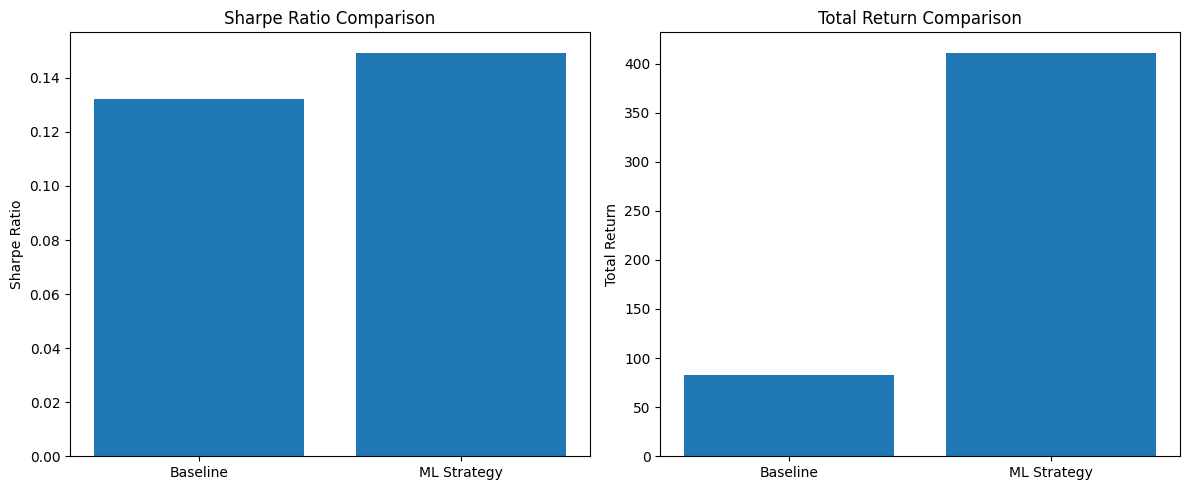

In [43]:
comparison = pd.DataFrame({
    'Baseline': {
        'Total Return': baseline_total_return,
        'Average Return': baseline_avg_return,
        'Sharpe Ratio': baseline_sharpe,
        'Number of Trades': len(baseline_returns)
    },
    'ML Strategy': {
        'Total Return': ml_total_return,
        'Average Return': ml_avg_return,
        'Sharpe Ratio': ml_sharpe,
        'Number of Trades': len(ml_returns)
    }
})

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(['Baseline', 'ML Strategy'], [baseline_sharpe, ml_sharpe])
plt.ylabel('Sharpe Ratio')
plt.title('Sharpe Ratio Comparison')

plt.subplot(1, 2, 2)
plt.bar(['Baseline', 'ML Strategy'], [baseline_total_return, ml_total_return])
plt.ylabel('Total Return')
plt.title('Total Return Comparison')

plt.tight_layout()
plt.show()


## SHAP Analysis


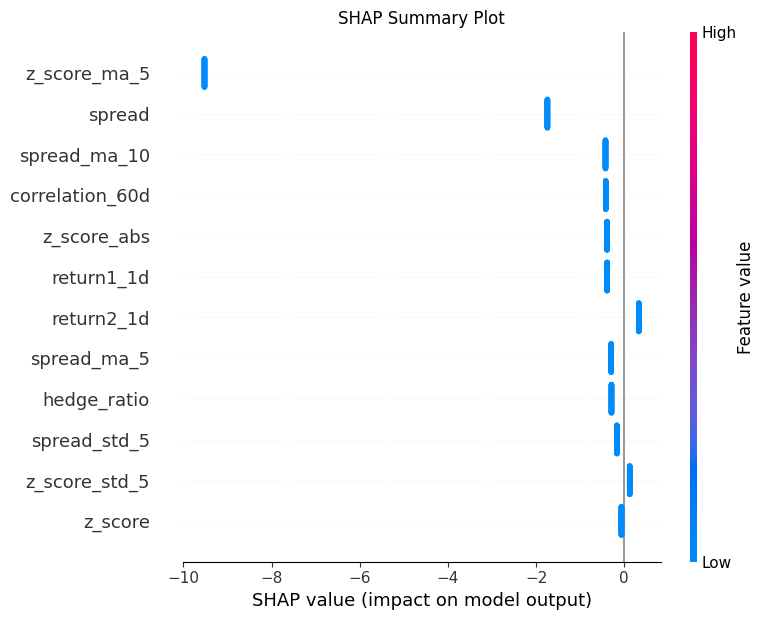

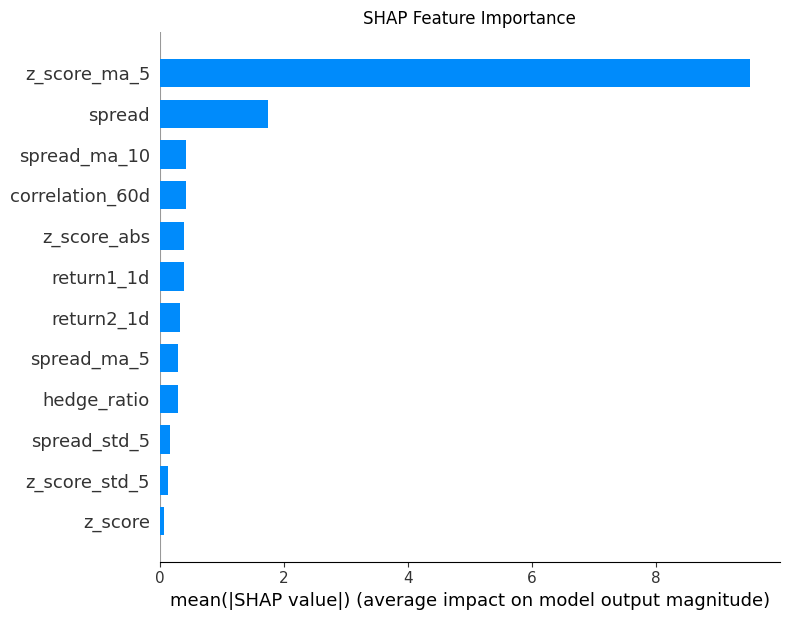

In [44]:
if xgb_optimized is not None:
    feature_importance = pd.read_csv('./dataset/stage5_stage4_feature_importance.csv')
    feature_cols = feature_importance['feature'].tolist()
    
    sample_size = min(100, len(predictions))
    sample_indices = np.random.choice(len(predictions), sample_size, replace=False)
    
    X_sample_list = []
    for idx in sample_indices:
        row = predictions.iloc[idx]
        features_dict = {
            'spread': row.get('spread', 0),
            'z_score': row.get('z_score', 0),
            'z_score_abs': abs(row.get('z_score', 0)),
            'hedge_ratio': row.get('hedge_ratio', 0),
            'spread_ma_5': row.get('spread_ma_5', 0),
            'spread_std_5': row.get('spread_std_5', 0),
            'z_score_ma_5': row.get('z_score_ma_5', 0),
            'z_score_std_5': row.get('z_score_std_5', 0),
            'spread_ma_10': row.get('spread_ma_10', 0),
            'return1_1d': row.get('return1_1d', 0),
            'return2_1d': row.get('return2_1d', 0),
            'correlation_60d': row.get('correlation_60d', 0)
        }
        X_sample_list.append(features_dict)
    
    X_sample = pd.DataFrame(X_sample_list)
    X_sample = X_sample.reindex(columns=feature_cols, fill_value=0)
    
    explainer = shap.TreeExplainer(xgb_optimized)
    shap_values = explainer.shap_values(X_sample)
    
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_sample, show=False)
    plt.title('SHAP Summary Plot')
    plt.tight_layout()
    plt.show()
    
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_sample, plot_type='bar', show=False)
    plt.title('SHAP Feature Importance')
    plt.tight_layout()
    plt.show()


## Save Results

In [46]:
results_summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Sharpe Ratio', 'Total Return', 'Avg Return per Trade'],
    'Baseline Strategy': [
        'N/A',
        'N/A',
        'N/A',
        'N/A',
        baseline_sharpe,
        baseline_total_return,
        baseline_avg_return
    ],
    'ML Strategy (XGBoost Optimized)': [
        models_metrics['XGBoost Optimized']['accuracy'],
        models_metrics['XGBoost Optimized']['precision'],
        models_metrics['XGBoost Optimized']['recall'],
        models_metrics['XGBoost Optimized']['f1_score'],
        ml_sharpe,
        ml_total_return,
        ml_avg_return
    ]
})

results_summary.to_csv('./dataset/stage6_evaluation_results.csv', index=False)
print("Results saved to ./dataset/stage6_evaluation_results.csv")


Results saved to ./dataset/stage6_evaluation_results.csv
